# 01 – Exploratory Data Analysis

This notebook provides an initial exploration of the dataset:
- Summary statistics
- Distribution plots
- Correlation analysis
- Pairplot

In [12]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [13]:
# Load data – update the path to point to your raw CSV file
df = pd.read_csv('../data/raw/Police_Department_Incident_Reports__2018_to_Present_20260413.csv')

/var/folders/3b/_701tnqj0_545vycfpjds_1r0000gn/T/ipykernel_24780/3758066189.py:2: DtypeWarning: Columns (18,21,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/raw/Police_Department_Incident_Reports__2018_to_Present_20260413.csv')


In [14]:

print(df.shape)
df.head()
print(df.columns.tolist())


(1022689, 29)
['Row ID', 'Incident Datetime', 'Incident Date', 'Incident Time', 'Incident Year', 'Incident Day of Week', 'Report Datetime', 'Incident ID', 'Incident Number', 'CAD Number', 'Report Type Code', 'Report Type Description', 'Filed Online', 'Incident Code', 'Incident Category', 'Incident Subcategory', 'Incident Description', 'Resolution', 'Intersection', 'CNN', 'Police District', 'Analysis Neighborhood', 'Supervisor District', 'Supervisor District 2012', 'Latitude', 'Longitude', 'Point', 'data_as_of', 'data_loaded_at']


In [15]:
# Summary statistics
df.describe()

,Row ID,Incident Year,Incident ID,Incident Number,CAD Number,Incident Code,CNN,Supervisor District,Supervisor District 2012,Latitude,Longitude
count,1.022689e+06,1.022689e+06,1.022689e+06,1.022689e+06,7.931080e+05,1.022689e+06,9.664840e+05,965848.000000,966392.000000,966484.000000,966484.000000
mean,1.094309e+11,2.021369e+03,1.094309e+06,2.152973e+08,2.167989e+08,2.420247e+04,2.575890e+07,5.989487,6.033939,37.768903,-122.423724
std,2.723714e+10,2.343934e+00,2.723714e+05,2.372737e+07,3.264877e+07,2.538351e+04,4.923183e+06,2.799429,2.785236,0.024374,0.026183
min,6.186871e+10,2.018000e+03,6.186870e+05,0.000000e+00,0.000000e+00,1.000000e+03,2.001300e+07,1.000000,1.000000,37.707848,-122.511940
25%,8.584511e+10,2.019000e+03,8.584510e+05,1.909597e+08,1.930028e+08,6.244000e+03,2.395100e+07,3.000000,3.000000,37.754002,-122.434059
50%,1.095180e+11,2.021000e+03,1.095180e+06,2.160574e+08,2.133323e+08,7.043000e+03,2.492500e+07,6.000000,6.000000,37.775799,-122.417587
75%,1.331046e+11,2.023000e+03,1.331046e+06,2.309085e+08,2.331724e+08,2.816000e+04,2.644600e+07,9.000000,9.000000,37.785492,-122.407349
max,1.562121e+11,2.026000e+03,1.562121e+06,9.901103e+08,1.000000e+09,7.503000e+04,5.441200e+07,11.000000,11.000000,37.830055,-122.366287


/var/folders/3b/_701tnqj0_545vycfpjds_1r0000gn/T/ipykernel_24780/3063249315.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Incident Datetime'] = pd.to_datetime(df['Incident Datetime'])


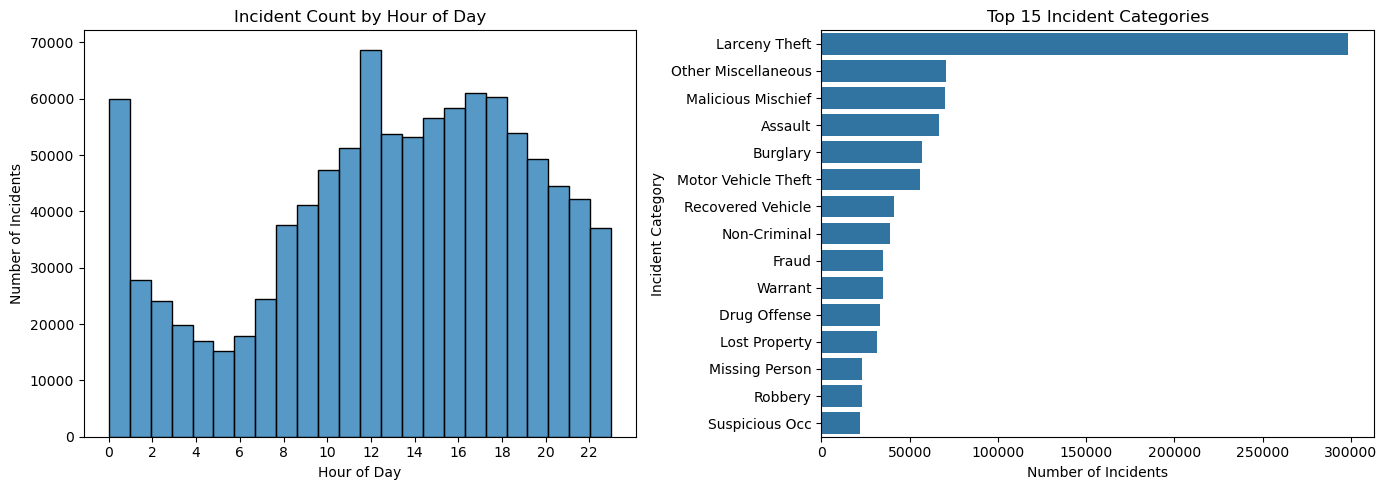

In [16]:
# Distribution of incidents by hour of day (target for point process)
df['Incident Datetime'] = pd.to_datetime(df['Incident Datetime'])
df['hour'] = df['Incident Datetime'].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hourly distribution
sns.histplot(df['hour'], bins=24, kde=False, ax=axes[0])
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Incidents')
axes[0].set_title('Incident Count by Hour of Day')
axes[0].set_xticks(range(0, 24, 2))

# Top 15 incident categories
category_counts = df['Incident Category'].value_counts()[:15]
sns.barplot(x=category_counts.values, y=category_counts.index, ax=axes[1])
axes[1].set_xlabel('Number of Incidents')
axes[1].set_ylabel('Incident Category')
axes[1].set_title('Top 15 Incident Categories')

fig.tight_layout()
plt.show()

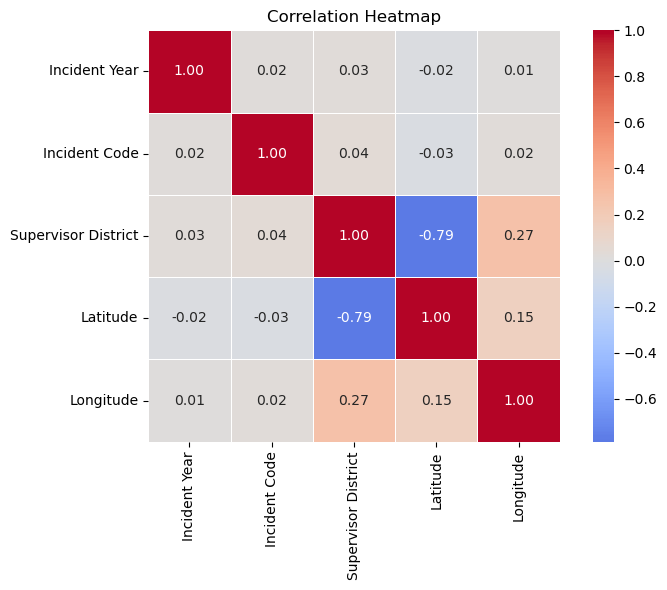

In [17]:
# Correlation heatmap of numeric features
numeric_cols = ['Incident Year', 'Incident Code', 'Supervisor District', 'Latitude', 'Longitude']
corr = df[numeric_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap')
fig.tight_layout()
plt.show()

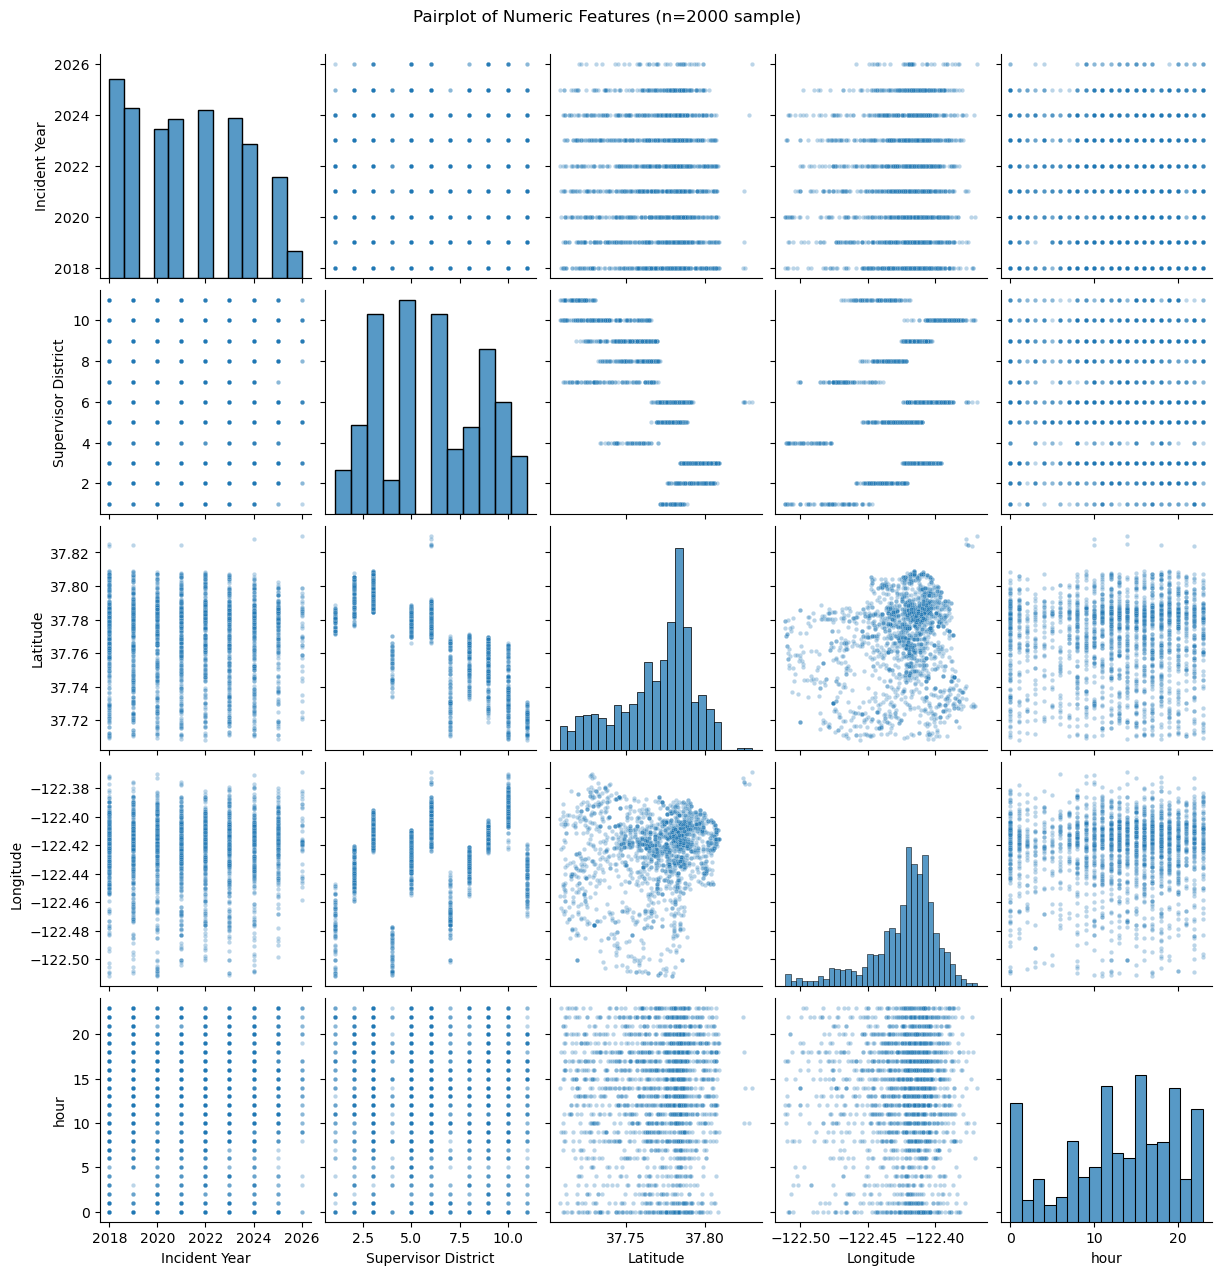

In [18]:
# Pairplot of numeric features (sampled for performance)
numeric_cols = ['Incident Year', 'Supervisor District', 'Latitude', 'Longitude', 'hour']
sample = df[numeric_cols].dropna().sample(2000, random_state=42)

fig = sns.pairplot(sample, plot_kws={'alpha': 0.3, 's': 10})
fig.fig.suptitle('Pairplot of Numeric Features (n=2000 sample)', y=1.02)
plt.show()

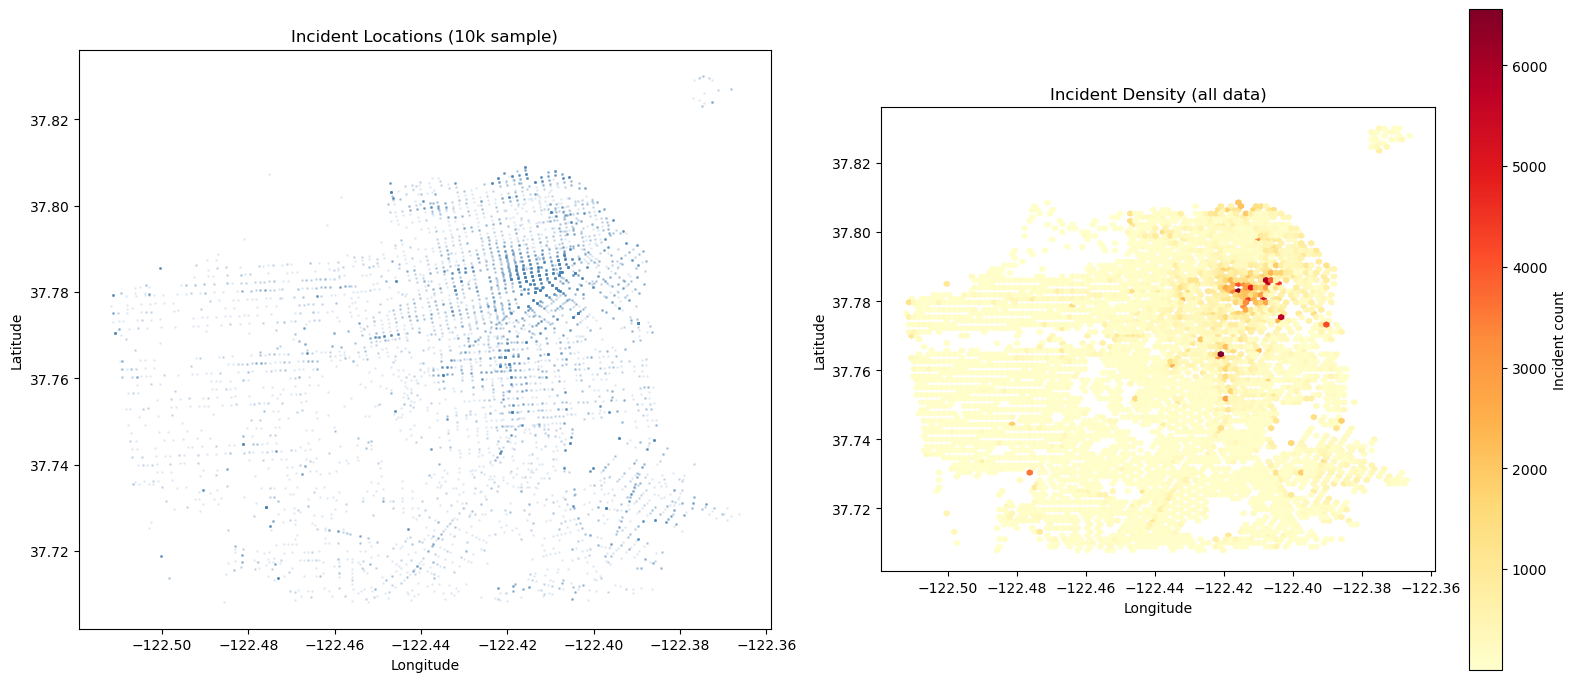

In [19]:
# Map of all incident locations
coords = df[['Longitude', 'Latitude']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Scatter plot (sampled)
sample = coords.sample(10000, random_state=42)
axes[0].scatter(sample['Longitude'], sample['Latitude'],
                alpha=0.1, s=1, color='steelblue')
axes[0].set_title('Incident Locations (10k sample)')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_aspect('equal')

# Hexbin density — uses all data
hb = axes[1].hexbin(coords['Longitude'], coords['Latitude'],
                    gridsize=100, cmap='YlOrRd', mincnt=1)
fig.colorbar(hb, ax=axes[1], label='Incident count')
axes[1].set_title('Incident Density (all data)')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_aspect('equal')

fig.tight_layout()
plt.show()